## Tesla EA Deliveries and Production Data(2015–2025)

## Overview

Tasks:
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Model Evaluation
- Forecasting

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import joblib

print('All libraries loaded successfully')

All libraries loaded successfully


In [7]:
df=pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


In [8]:
df.head(10)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [9]:
df.sample(5)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
1137,2023,2,North America,Model Y,7173,7344,64362.80,100,589,633.73,Estimated (Region),5006
2289,2018,8,Middle East,Model 3,6056,6666,101051.69,75,434,394.25,Official (Quarter),5481
581,2017,10,Asia,Model S,11012,12619,82550.67,75,444,733.40,Estimated (Region),3748
1407,2017,12,Europe,Model 3,7124,7492,52107.27,82,490,523.61,Interpolated (Month),11014
1185,2025,1,Asia,Cybertruck,10494,11614,54090.17,60,346,544.64,Official (Quarter),4016


In [10]:
df.shape

(2640, 12)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [12]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [13]:
print('Missing Values')
df.isnull().sum()

Missing Values


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [14]:
print('Duplicated Values')
df.duplicated().sum()

Duplicated Values


np.int64(0)

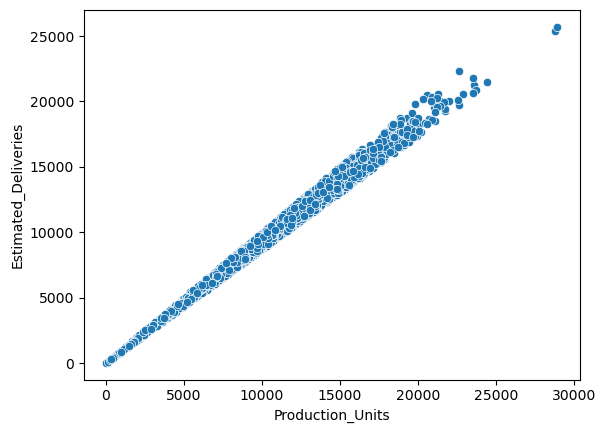

In [15]:
sns.scatterplot(data=df,x='Production_Units',y='Estimated_Deliveries')
plt.show()

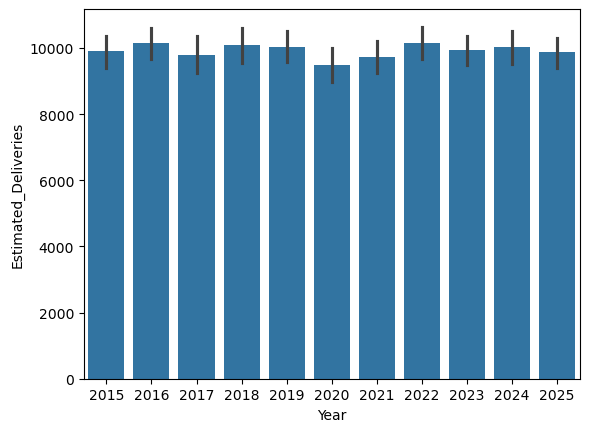

In [16]:
sns.barplot(data=df,x='Year',y='Estimated_Deliveries')
plt.show()

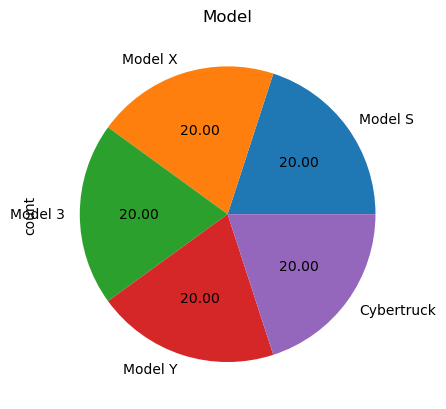

<Figure size 300x400 with 0 Axes>

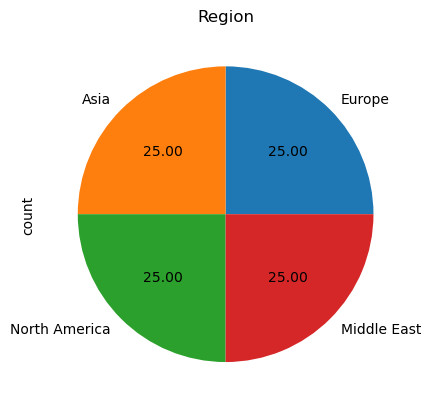

<Figure size 300x400 with 0 Axes>

In [17]:
label=['Model','Region']
for i in label:
    df[i].value_counts().plot(kind='pie',autopct='%.2f')
    plt.title(i)
    plt.subplot(111)
    plt.figure(figsize=(3,4))
    plt.show()

C:\Users\golu\AppData\Local\Temp\ipykernel_25612\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


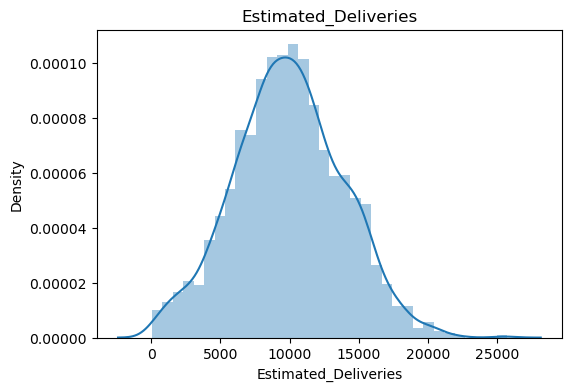

C:\Users\golu\AppData\Local\Temp\ipykernel_25612\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


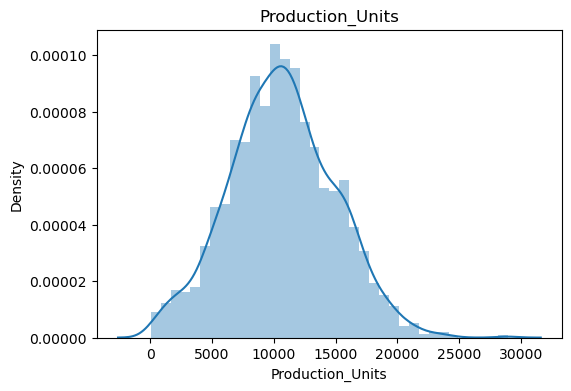

C:\Users\golu\AppData\Local\Temp\ipykernel_25612\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


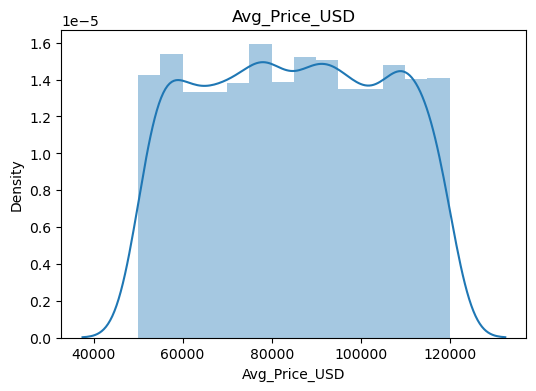

C:\Users\golu\AppData\Local\Temp\ipykernel_25612\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


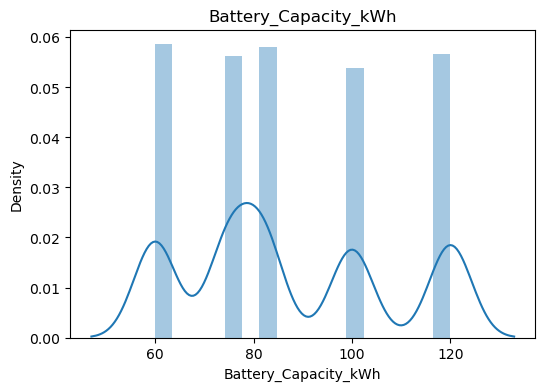

C:\Users\golu\AppData\Local\Temp\ipykernel_25612\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


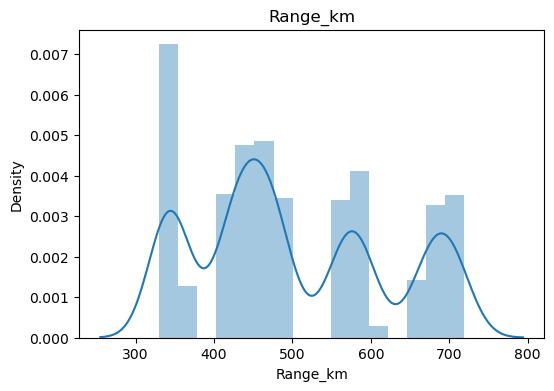

C:\Users\golu\AppData\Local\Temp\ipykernel_25612\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


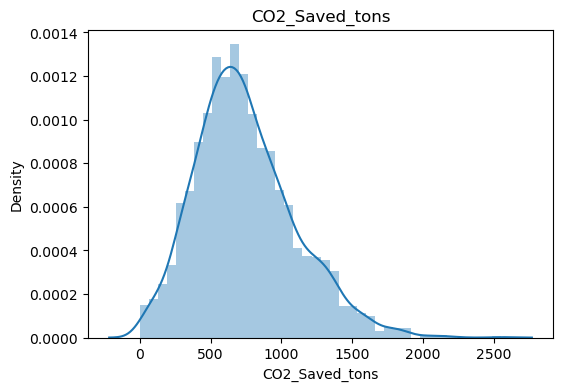

C:\Users\golu\AppData\Local\Temp\ipykernel_25612\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


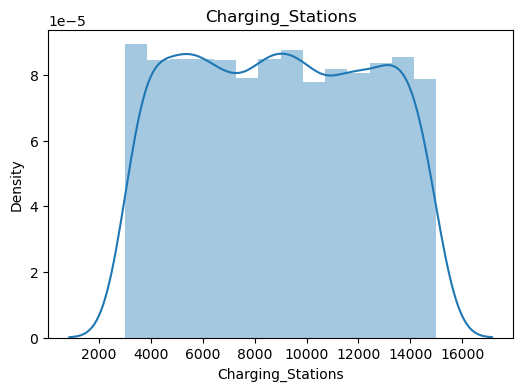

In [18]:
plot=['Estimated_Deliveries',	'Production_Units',	'Avg_Price_USD',	'Battery_Capacity_kWh',	'Range_km',	'CO2_Saved_tons','Charging_Stations']
for i in plot:
    plt.figure(figsize=(6,4))
    sns.distplot(df[i],kde=True)
    plt.title(i)
    plt.show()

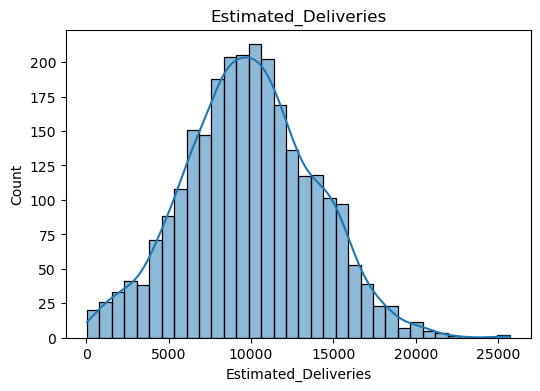

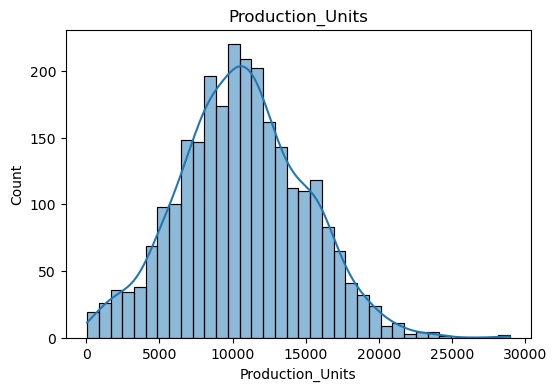

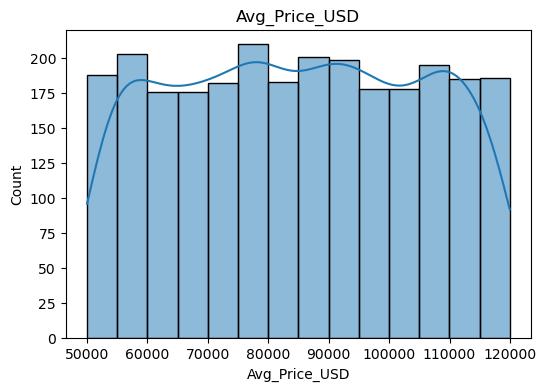

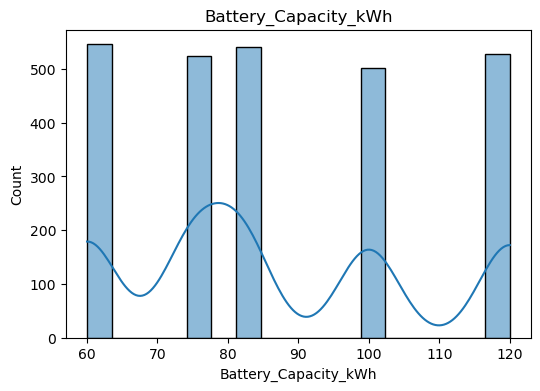

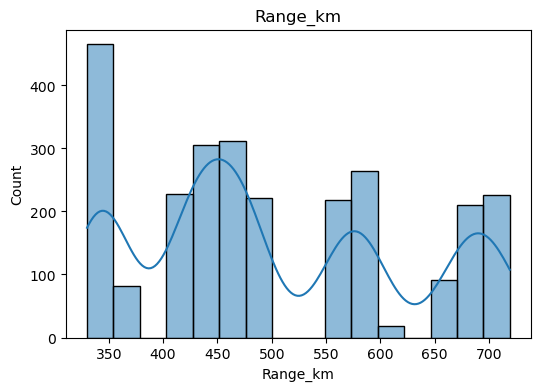

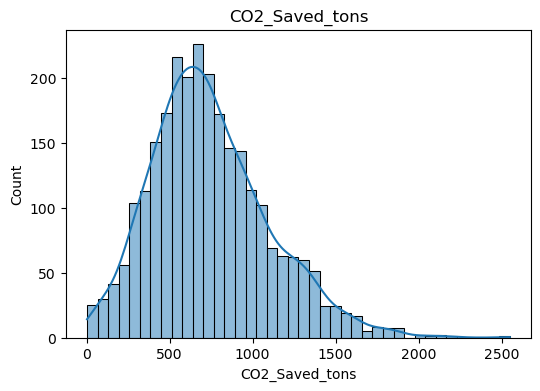

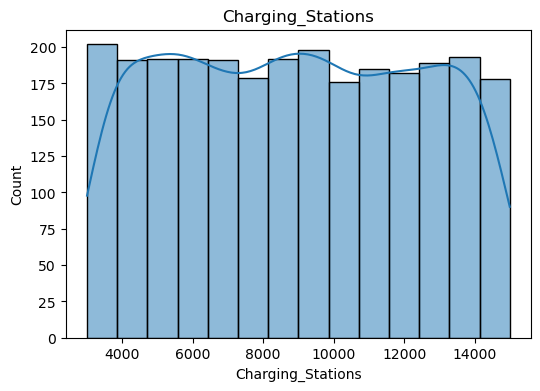

In [19]:
plots=['Estimated_Deliveries',	'Production_Units',	'Avg_Price_USD',	'Battery_Capacity_kWh',	'Range_km',	'CO2_Saved_tons','Charging_Stations']
for i in plots:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i],kde=True)
    plt.title(i)
    plt.show()
    

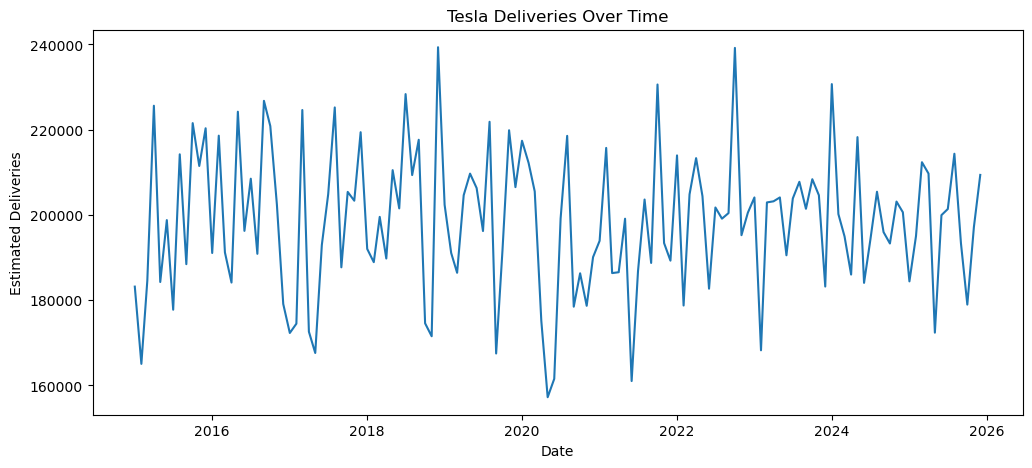

In [25]:
df["Date"] =pd.to_datetime(df["Year"].astype(str)+ "-"+ df["Month"].astype(str))
monthly_sales = (df.groupby("Date")["Estimated_Deliveries"].sum())
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index,monthly_sales.values)
plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

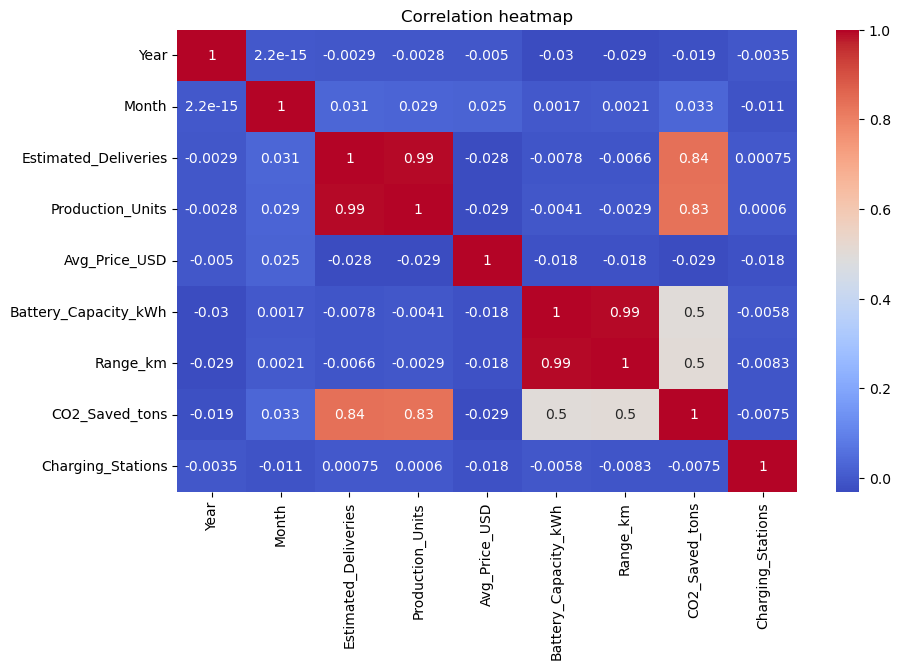

In [26]:
df = df.drop(columns=['Date'])
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

In [27]:
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

In [29]:
df['month_sin'] = np.sin(2*np.pi*df['Month']/12)
df['month_cos'] = np.cos(2*np.pi*df['Month']/12)
df['Year'] = df['Year'] - df['Year'].min()

In [30]:
print('Identifying the numerical and categorical Feature')
nume_col=X.select_dtypes(include=['int64','float64']).columns.tolist()
cate_col=X.select_dtypes(include='object').columns.tolist()
print(f"Numerical Features: {nume_col}\n")
print(f"Categorical Features: {cate_col}")

Identifying the numerical and categorical Feature
Numerical Features: ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

Categorical Features: ['Region', 'Model', 'Source_Type']


In [31]:
print('Identifying the sub categories in the categorical features\n')
for i in cate_col:
    print(f'{df[i].value_counts()}\n')

Identifying the sub categories in the categorical features

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64



In [32]:
processor=ColumnTransformer(transformers=[
    ('num',StandardScaler(),nume_col),
    ('cat',OneHotEncoder(handle_unknown='ignore'),cate_col)
],remainder='passthrough')

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type',
       'Charging_Stations'],
      dtype='object')


In [34]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,month_sin,month_cos
0,8,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,5.000000e-01,-0.866025
1,0,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,8.660254e-01,0.500000
2,4,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,5.000000e-01,0.866025
3,6,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,8.660254e-01,0.500000
4,1,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,-2.449294e-16,1.000000


In [35]:
pipe = Pipeline([
    ('processor', processor),
    ('model', LinearRegression())
])

In [36]:
pipe.fit(X_train, y_train)

,steps,"[('processor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
y_pred = pipe.predict(X_test)
y_pred.tolist()

[7571.600001457932,
 9433.89473939124,
 8799.017878963092,
 9366.321985159831,
 8922.60215210729,
 11482.734132524829,
 14204.708819721396,
 14341.476515619026,
 10003.073095865999,
 7858.434134677136,
 8552.280913933511,
 9910.327333366025,
 9660.867723784004,
 3130.7550440068962,
 10373.78141372012,
 5960.770420305724,
 11566.507853034367,
 11772.434176189596,
 17073.86937808025,
 10900.99497244522,
 10596.527166768241,
 7750.474563137421,
 9682.845719884257,
 10561.465041001158,
 8194.550641488553,
 6187.7905143258895,
 13352.182654790558,
 4502.077299359918,
 10689.216433507556,
 3427.177403380324,
 8551.62825753141,
 13887.974604002224,
 14723.518366118733,
 15746.022312181622,
 13937.367493015965,
 12722.96900965293,
 4379.040157617292,
 9412.100192013906,
 4827.9825227148,
 14630.11433753606,
 9333.707650334662,
 9079.813495924804,
 5998.218387143988,
 16033.062133368776,
 7630.1248550356995,
 4929.686166738956,
 10433.212988260639,
 4461.694992594443,
 2073.315618946871,
 15453

In [38]:
forecast=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
forecast

,Actual,Predicted
2005,6991,7571.600001
32,9326,9433.894739
962,9061,8799.017879
1461,8951,9366.321985
478,8707,8922.602152
...,...,...
2033,18572,19123.109199
279,1761,1965.343810
2443,10136,10707.193283
2356,17905,18265.209067


In [39]:
lr_mae = mean_absolute_error(y_test, y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_r2 = r2_score(y_test,y_pred)
print("---------------------")
print("MAE :", round(lr_mae,2))
print("RMSE:", round(lr_rmse,2))
print("R²  :", round(lr_r2,4))

---------------------
MAE : 309.7
RMSE: 384.03
R²  : 0.9901


In [40]:
scores = cross_val_score(pipe,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)
print("Cross Validation Scores:", scores)
print("Mean CV Score:", scores.mean())
print("Std CV Score:", scores.std())

Cross Validation Scores: [0.99055199 0.99044416 0.99005516 0.98946291 0.99048545]
Mean CV Score: 0.9901999337873952
Std CV Score: 0.0004072532581680656


In [41]:
joblib.dump(pipe, "tesla_delivery_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully
